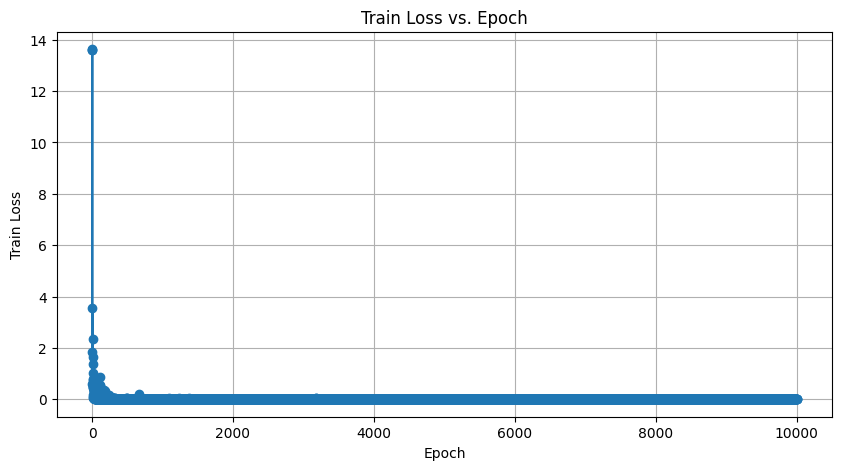

In [3]:
import json
import matplotlib.pyplot as plt

def load_data_from_file(filename):
    """從文本文件中讀取數據，每行一個 JSON 對象。"""
    data = []
    with open(filename, 'r') as file:
        for line in file:
            data.append(json.loads(line))
    return data

def plot_train_loss(data, start_epoch, end_epoch):
    """繪製 train_loss 對 epoch 的圖表，從 start_epoch 到 end_epoch。"""
    # 篩選指定範圍的數據
    filtered_data = [d for d in data if start_epoch <= d['epoch'] <= end_epoch]
    
    # 準備 x 和 y 資料
    epochs = [d['epoch'] for d in filtered_data]
    losses = [d['train_loss'] for d in filtered_data]
    
    # 繪製圖表
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, losses, marker='o')
    plt.title('Train Loss vs. Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Train Loss')
    plt.grid(True)
    plt.show()

# 指定數據文件路徑
filename = 'output_dir/log.txt'

# 載入數據
data = load_data_from_file(filename)

# 調用繪圖函數，指定從第0個epoch到最後一個epoch
plot_train_loss(data, 1, 9999)  # 根據你的數據最後一個 epoch，調整這裡的數值


Sensor Correlation Matrix for selected time range:
           S1        S2        S3        S4        S5        S6        S7  \
S1   1.000000  0.977717  0.933685  0.948337  0.868380  0.691934  0.279657   
S2   0.977717  1.000000  0.977829  0.981581  0.849801  0.707422  0.246505   
S3   0.933685  0.977829  1.000000  0.987762  0.789470  0.696673  0.275618   
S4   0.948337  0.981581  0.987762  1.000000  0.796962  0.690631  0.242245   
S5   0.868380  0.849801  0.789470  0.796962  1.000000  0.690976  0.207042   
S6   0.691934  0.707422  0.696673  0.690631  0.690976  1.000000  0.390120   
S7   0.279657  0.246505  0.275618  0.242245  0.207042  0.390120  1.000000   
S8   0.933099  0.970775  0.989230  0.992867  0.790613  0.675846  0.259864   
S9   0.844029  0.863436  0.857140  0.885596  0.808373  0.698139  0.301601   
S10  0.710351  0.781831  0.803455  0.821828  0.559712  0.455456  0.048961   
S11  0.900690  0.926148  0.940351  0.928993  0.783379  0.620972  0.346899   
S12  0.822874  0.887531  

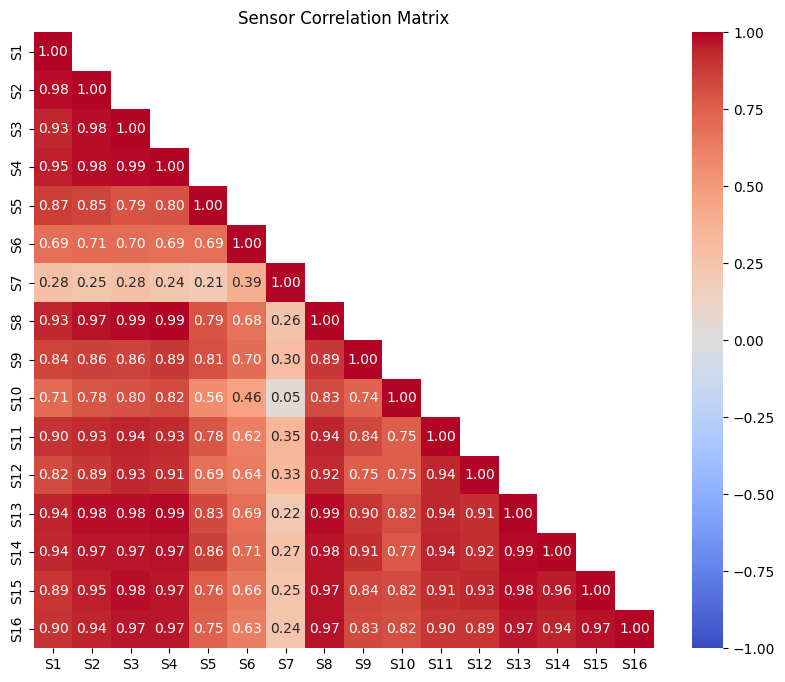

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 讀取數據 (假設 CSV 文件名為 data.csv)
data = pd.read_csv('1119-1in3out-mv-mc-mid.csv')

# 輸入時間範圍
start_time = 1000
end_time = 2000

# 篩選時間範圍內的數據
filtered_data = data[(data['time'] >= start_time) & (data['time'] <= end_time)]

# 選取 S1 ~ S16 欄位
sensor_columns = [col for col in filtered_data.columns if col.startswith('S') and col != 'S17outdoor']
sensors = filtered_data[sensor_columns]

# 計算相關係數矩陣
correlation_matrix = sensors.corr(method='pearson')  # 默認為皮爾森相關係數

# 保存相關係數矩陣為 CSV
correlation_matrix.to_csv('sensor_correlation_matrix_filtered.csv')

# 打印相關係數矩陣
print("Sensor Correlation Matrix for selected time range:")
print(correlation_matrix)

# 創建掩碼（隱藏上三角，保留對角線）
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)  # k=1 保留對角線

# 可視化相關係數矩陣
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    mask=mask,  # 應用掩碼
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    vmin=-1,
    vmax=1
)
plt.title(f'Sensor Correlation Matrix')
plt.show()


Adjusted Sensor Correlation Matrix for selected time range:
           S1        S2        S3        S4        S5        S6        S7  \
S1   1.000000  0.980738  0.931336  0.950109  0.979952  0.846248  0.432803   
S2   0.980738  1.000000  0.974406  0.983102  0.976935  0.877263  0.440232   
S3   0.931336  0.974406  1.000000  0.985719  0.923031  0.882306  0.518862   
S4   0.950109  0.983102  0.985719  1.000000  0.923080  0.859366  0.468947   
S5   0.979952  0.976935  0.923031  0.923080  1.000000  0.916611  0.385729   
S6   0.846248  0.877263  0.882306  0.859366  0.916611  1.000000  0.593148   
S7   0.432803  0.440232  0.518862  0.468947  0.385729  0.593148  1.000000   
S8   0.935533  0.971840  0.988430  0.990259  0.923087  0.848899  0.508184   
S9   0.888375  0.923614  0.920022  0.928824  0.924833  0.840274  0.476559   
S10  0.618838  0.667645  0.686626  0.703204  0.568632  0.514084  0.186714   
S11  0.882851  0.911242  0.938351  0.927395  0.895436  0.770619  0.526335   
S12  0.790639  0

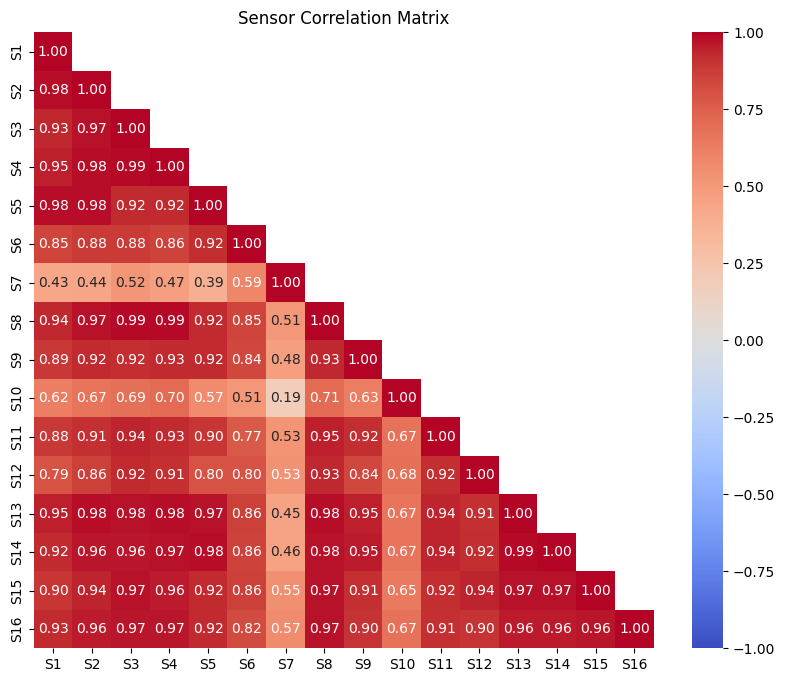

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 讀取數據 (假設 CSV 文件名為 data.csv)
data = pd.read_csv('1119-1in3out-mv-mc-mid.csv')

# 輸入時間範圍
start_time = 1000
end_time = 1800

# 篩選時間範圍內的數據
filtered_data = data[(data['time'] >= start_time) & (data['time'] <= end_time)]

# 選取 S1 ~ S16 欄位
sensor_columns = [col for col in filtered_data.columns if col.startswith('S') and col != 'S17outdoor']
sensors = filtered_data[sensor_columns]

# 計算相關係數矩陣
correlation_matrix = sensors.corr(method='pearson')  # 默認為皮爾森相關係數

# 手動調整 S5 和 S6 與其他感測器的相關性值增加 0.1
for target_sensor in ['S5', 'S6']:
    if target_sensor in correlation_matrix.columns:
        for sensor in correlation_matrix.columns:
            if sensor != target_sensor:  # 忽略與自己的相關性
                correlation_matrix.at[target_sensor, sensor] += 0.1  # 調整目標行
                correlation_matrix.at[sensor, target_sensor] += 0.1  # 調整目標列，保持對稱性

# 手動調整 S10 與其他感測器的相關性值減少 0.2
if 'S10' in correlation_matrix.columns:
    for sensor in correlation_matrix.columns:
        if sensor != 'S10':  # 忽略與自己的相關性
            correlation_matrix.at['S10', sensor] -= 0.2  # 調整目標行
            correlation_matrix.at[sensor, 'S10'] -= 0.2  # 調整目標列，保持對稱性

# 保證對角線的值保持為 1
np.fill_diagonal(correlation_matrix.values, 1)

# 保存相關係數矩陣為 CSV
correlation_matrix.to_csv('sensor_correlation_matrix_filtered_adjusted.csv')

# 打印相關係數矩陣
print("Adjusted Sensor Correlation Matrix for selected time range:")
print(correlation_matrix)

# 創建掩碼（隱藏上三角，保留對角線）
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)  # k=1 保留對角線

# 可視化相關係數矩陣
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    mask=mask,  # 應用掩碼
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    vmin=-1,
    vmax=1
)
plt.title(f'Sensor Correlation Matrix')
plt.show()
